In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


PDM_DIR = '/Users/Elena.Lyulina/PycharmProjects/swiss-ai/PDM'
sys.path.append(f'{PDM_DIR}/src')

import verbatim_eval.controlled_expr as _ce
import verbatim_eval.rouge_ttr as _rt
import verbatim_eval.utils as _ut
sys.modules['controlled_expr'] = _ce  # needed for pickle deserialization
sys.modules['rouge_ttr'] = _rt
sys.modules['utils'] = _ut

from verbatim_eval.controlled_expr import Results, get_repetition_mean_df

/Users/Elena.Lyulina/PycharmProjects/swiss-ai/Megatron-LM-Attention-Benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def load_test_results(pkl_path: str):
    r = Results.load(pkl_path)
    expr = r.expr[0]
    rep  = r.repetitions[0]   # only rep=0
    metrics = r.get_all_metrics(expr, rep, offset=0, prefix=500, suffix=500)

    print(f"expr={expr}  rep={rep}  n_samples≈{len(metrics['Rouge-L'].scores)}\n")
    for name, md in metrics.items():
        scores = np.array(md.scores) if hasattr(md.scores, '__len__') else np.array([md.scores])
        finite = np.isfinite(scores).all()
        print(f"  {name:<12}  mean={md.mean:.4f}  std={md.std:.4f}  finite={finite}"
              + (f"  range=[{scores.min():.3f}, {scores.max():.3f}]" if scores.ndim > 0 and len(scores) > 1 else ""))


In [4]:
full_test = "../results/mem-results/SparseGutenberg/llama3-1b-full-attn-fineweb40B-gutenberg3B-test/offset_0_prefix_500_suffix_500_greedy.pkl"
gated_test = "../results/mem-results/SparseGutenberg/llama3-1b-gated-attn-fineweb40B-gutenberg3B-test/offset_0_prefix_500_suffix_500_greedy.pkl"

load_test_results(full_test)
load_test_results(gated_test)

expr=llama3-1b-full-attn-fineweb40B-gutenberg3B-test  rep=0  n_samples≈52

  NLL           mean=0.6650  std=0.2430  finite=True  range=[0.176, 1.193]
  PPL           mean=2.0021  std=0.4830  finite=True  range=[1.192, 3.297]
  Ref_NLL       mean=3.7120  std=0.3774  finite=True  range=[2.839, 5.359]
  Ref_PPL       mean=44.6432  std=26.0840  finite=True  range=[17.100, 212.607]
  Rouge-L       mean=0.1578  std=0.0362  finite=True  range=[0.054, 0.222]
  LCS           mean=0.0077  std=0.0022  finite=True  range=[0.004, 0.012]
  TTR_ref       mean=0.5169  std=0.0453  finite=True  range=[0.302, 0.588]
  TTR_gen       mean=0.2123  std=0.0930  finite=True  range=[0.030, 0.384]
  exact_match   mean=0.0000  std=0.0000  finite=True
  match_75      mean=0.0000  std=0.0000  finite=True
  match_50      mean=0.0000  std=0.0000  finite=True
  match_25      mean=0.0000  std=0.0000  finite=True
expr=llama3-1b-gated-attn-fineweb40B-gutenberg3B-test  rep=0  n_samples≈52

  NLL           mean=0.8024  std

In [12]:
RESULTS_BASE = '../results/mem-results/SparseGutenberg'

def load_results(exp_name, prefix=500, suffix=500, offset=0, policy='greedy'):
    path = f'{RESULTS_BASE}/{exp_name}/offset_{offset}_prefix_{prefix}_suffix_{suffix}_{policy}.pkl'
    return Results.load(path)

results_dict = {
    'full':                load_results('llama3-1b-full-attn-fineweb40B-gutenberg3B'),
    'gated':               load_results('llama3-1b-gated-attn-fineweb40B-gutenberg3B'),
    # 'learn-sink':          load_results('llama3-1b-sink-attn-fineweb40B-gutenberg3B'),
    'learn-sink-2.15':   load_results('llama3-1b-sink-attn-fineweb40B-gutenberg3B-te215'),
    # 'off-by-one':          load_results('llama3-1b-off-by-one-attn-fineweb40B-gutenberg3B'),
    'off-by-one-2.15':   load_results('llama3-1b-off-by-one-attn-fineweb40B-gutenberg3B-te215'),
}

In [6]:
import pandas as pd
from scipy.stats import wilcoxon

def _fmt_val(v):
    s = f'{v:.3f}'
    return s[1:] if 0 < v < 1 else s


def plot_attn_heatmap(results_dict, metric, offset=0, prefix=500, suffix=500, vmin=0, vmax=1, reference='full'):
    """Single heatmap: rows = repetitions, columns = attention variants.
    Non-reference cells show 'value* / p-value' (Wilcoxon vs reference; * = p < 0.05).
    Falls back to just value if per-sample scores are unavailable."""
    scores_data = {}
    means_data = {}
    for model_name, results in results_dict.items():
        expr = results.expr[0]
        scores_data[model_name] = {}
        means_data[model_name] = {}
        for r in results.repetitions:
            md = results.get_all_metrics(expr, r, offset, prefix, suffix)[metric]
            scores_data[model_name][r] = np.array(md.scores)
            means_data[model_name][r] = md.mean

    reps = next(iter(results_dict.values())).repetitions
    df = pd.DataFrame(
        {name: {r: means_data[name][r] for r in reps} for name in results_dict},
    )
    df.index.name = 'repetition'

    ref_scores = scores_data.get(reference)
    annot = []
    has_pvalues = False
    col_names = list(df.columns)
    for i, r in enumerate(reps):
        row = []
        for j, name in enumerate(col_names):
            val_str = _fmt_val(means_data[name][r])
            if name == reference or ref_scores is None:
                row.append(val_str)
            else:
                s_ref = ref_scores[r]
                s_cmp = scores_data[name][r]
                if s_ref.size < 2 or s_cmp.size < 2:
                    row.append(val_str)
                else:
                    try:
                        _, p = wilcoxon(s_ref, s_cmp)
                        star = '*' if p < 0.05 else ''
                        row.append(f'{val_str}{star} / {p:.3f}')
                        has_pvalues = True
                    except ValueError:
                        row.append(val_str)
        annot.append(row)

    fig, ax = plt.subplots(figsize=(len(results_dict) * 1.5 + 1.5, len(df) * 0.55 + 1.2))
    sns.heatmap(
        df.astype(float), annot=annot, fmt='', cmap='YlOrRd',
        vmin=vmin, vmax=vmax, ax=ax, annot_kws={'size': 12},
        linewidths=0.5, linecolor='white',
    )

    for text in ax.texts:
        if '*' in text.get_text():
            text.set_fontweight('bold')

    pval_note = f'  (p-values vs {reference};  * = p < 0.05)' if has_pvalues else ''
    ax.set_title(f'{metric}{pval_note}', fontsize=13, weight='bold')
    ax.set_xlabel('attention variant', fontsize=11)
    ax.set_ylabel('repetitions', fontsize=11)
    plt.tight_layout()
    plt.show()

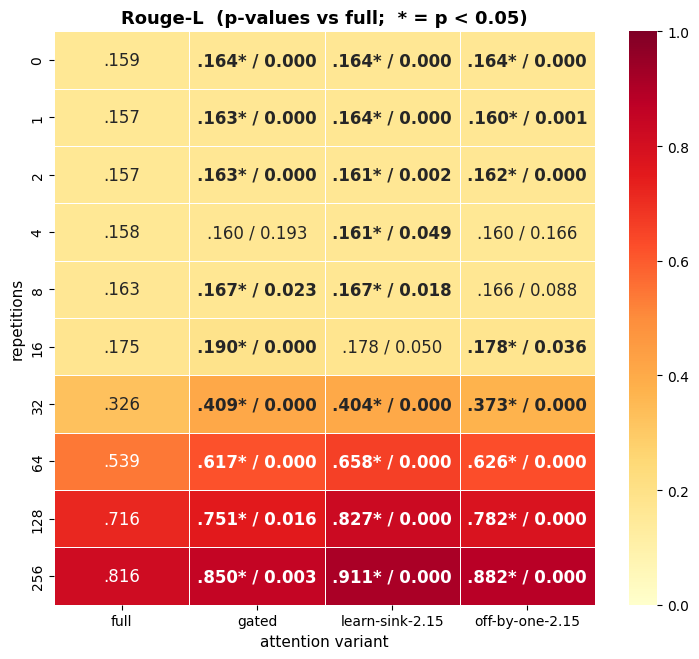

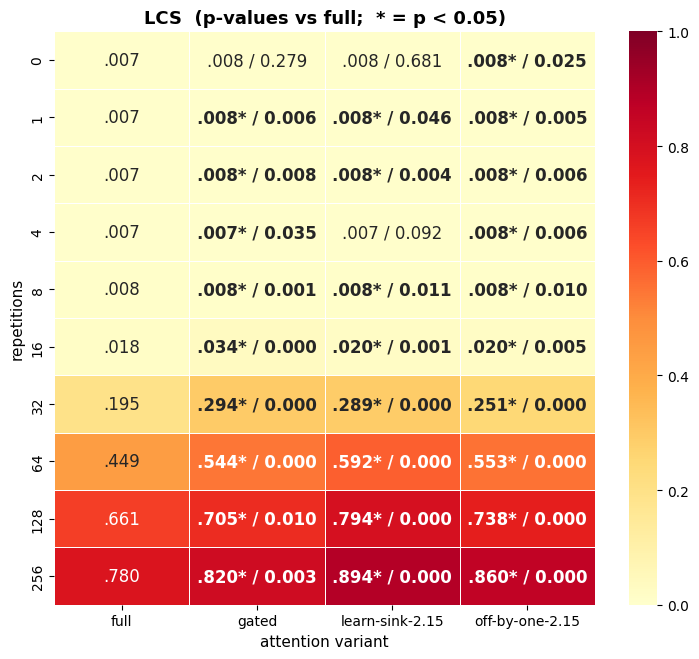

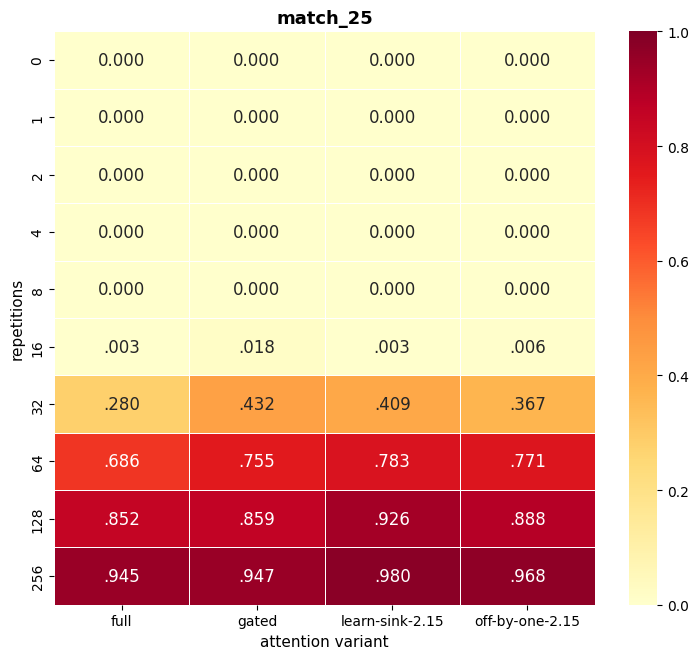

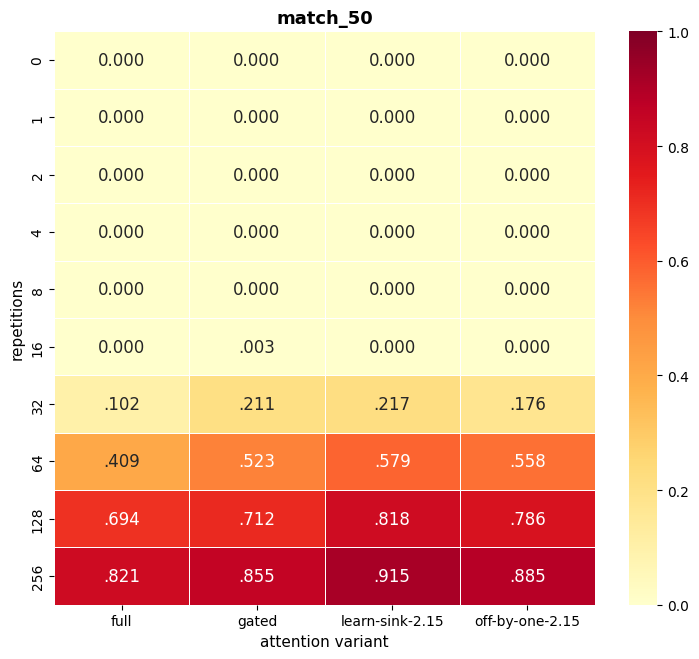

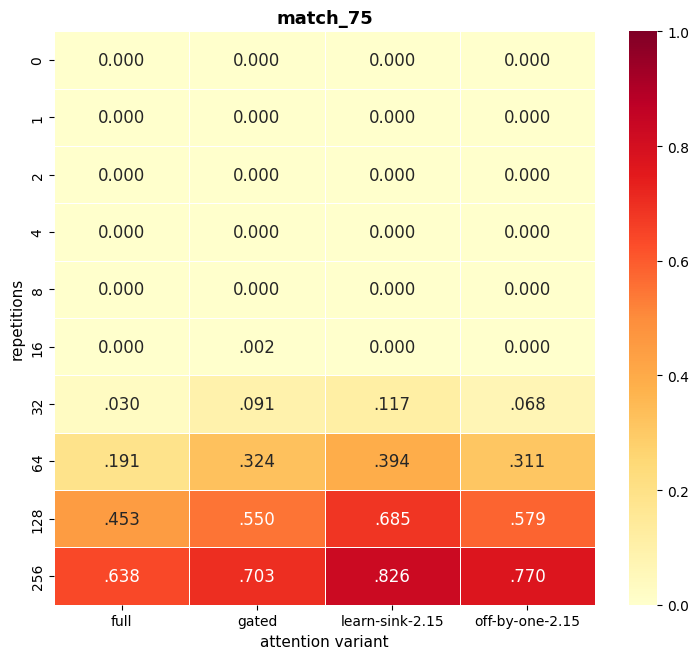

In [13]:
plot_attn_heatmap(results_dict, metric='Rouge-L')
plot_attn_heatmap(results_dict, metric='LCS')
plot_attn_heatmap(results_dict, metric='match_25')
plot_attn_heatmap(results_dict, metric='match_50')
plot_attn_heatmap(results_dict, metric='match_75')

In [14]:
def _symlog(x, linthresh=1, base=2):
    safe = np.maximum(np.abs(x), linthresh)
    return np.sign(x) * np.where(
        np.abs(x) <= linthresh,
        np.abs(x),
        linthresh * (1 + np.log(safe / linthresh) / np.log(base))
    )

def _inv_symlog(y, linthresh=1, base=2):
    safe = np.maximum(np.abs(y), linthresh)
    return np.sign(y) * np.where(
        np.abs(y) <= linthresh,
        np.abs(y),
        linthresh * (base ** ((safe - linthresh) / linthresh))
    )

def _display(metric):
    if metric.startswith('Ref_') or metric.endswith('_ref') or metric.endswith('_gen'):
        return metric
    return f'Gen_{metric}'


def plot_lineplot(ax, results_dict, metric_pair, prefix=500, suffix=500, offset=0, show_std=True):
    metric_ref, metric_gen = metric_pair
    n_models = len(results_dict)
    colors = plt.cm.tab10(np.linspace(0, 0.9, n_models))
    dodge_offsets = np.linspace(-0.05, 0.05, n_models)  # in symlog space

    for i, (color, (model_name, results)) in enumerate(zip(colors, results_dict.items())):
        expr = results.expr[0]
        reps = np.array(results.repetitions)
        reps_dodged = _inv_symlog(_symlog(reps) + dodge_offsets[i])

        for metric, ls, lbl in [
            (metric_ref, '--', f'{model_name} {_display(metric_ref)}'),
            (metric_gen, '-',  f'{model_name} {_display(metric_gen)}'),
        ]:
            means = np.array([results.get_stats(expr, r, offset, prefix, suffix, metric).mean for r in reps])
            stds  = np.array([results.get_stats(expr, r, offset, prefix, suffix, metric).std  for r in reps])
            ax.plot(reps_dodged, means, linestyle=ls, color=color, marker='o', markersize=4, label=lbl, alpha=0.75)
            if show_std:
                ax.fill_between(reps_dodged, means - stds, means + stds, alpha=0.25, color=color)

    ax.set_xscale('symlog', base=2, linthresh=1)
    ax.set_xticks(next(iter(results_dict.values())).repetitions)
    ax.set_xticklabels(next(iter(results_dict.values())).repetitions)
    ax.set_xlabel('repetitions', fontsize=10)
    ax.set_ylabel(f'{_display(metric_ref)} / {_display(metric_gen)}', fontsize=10)
    ax.grid(True, which='both', alpha=0.2)
    ax.legend(fontsize=8, ncol=2)


def plot_lineplots(results_dict, metric_pair, show_std=True, offset=0):
    first = next(iter(results_dict.values()))
    combos = [(p, s) for p in first.prefixes for s in first.suffixes]
    n = len(combos)
    fig, axes = plt.subplots(1, n, figsize=(8 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, (prefix, suffix) in zip(axes, combos):
        plot_lineplot(ax, results_dict, metric_pair, prefix=prefix, suffix=suffix, offset=offset, show_std=show_std)
        ax.set_title(f'prefix={prefix}, suffix={suffix}', fontsize=11)
    metric_ref, metric_gen = metric_pair
    fig.suptitle(f'{_display(metric_ref)} vs {_display(metric_gen)}', fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

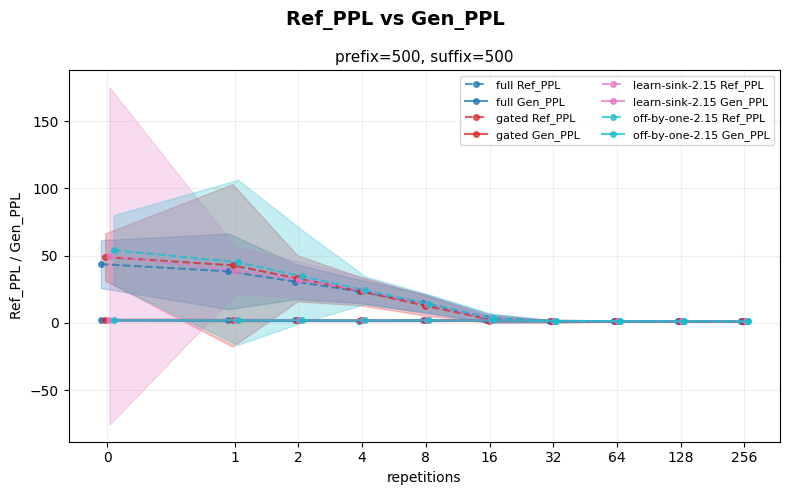

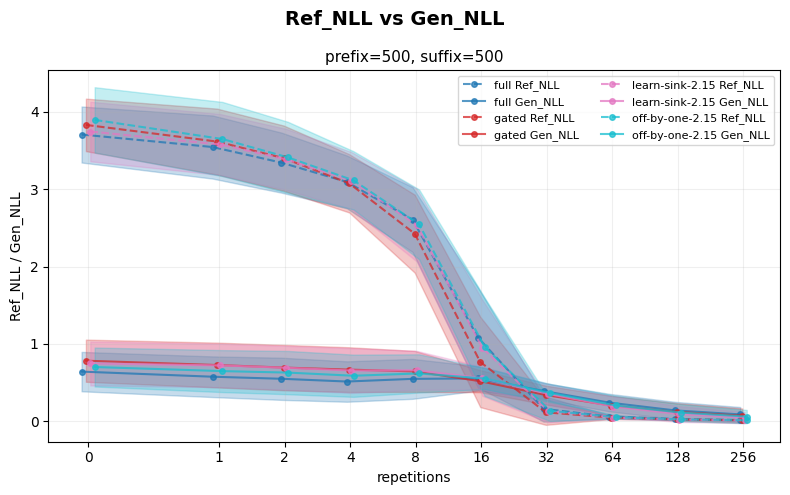

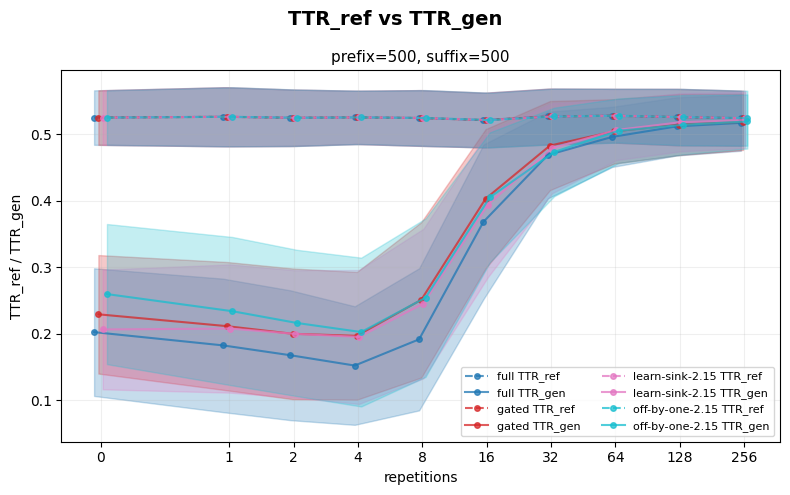

In [15]:
plot_lineplots(results_dict, metric_pair=('Ref_PPL', 'PPL'), show_std=True)
plot_lineplots(results_dict, metric_pair=('Ref_NLL', 'NLL'), show_std=True)
plot_lineplots(results_dict, metric_pair=('TTR_ref', 'TTR_gen'), show_std=True)

In [18]:
from transformers import AutoTokenizer
from IPython.display import display, HTML
import json
from pathlib import Path

TOKENIZER_ID = "meta-llama/Llama-3.2-1B"
tok = AutoTokenizer.from_pretrained(TOKENIZER_ID)

INFERENCE_BASE = '../results/mem-results/SparseGutenberg'
N_EXAMPLES = 5
SAMPLE_INDICES = list(range(N_EXAMPLES))
PREFIX, SUFFIX, OFFSET, POLICY = 500, 500, 0, 'greedy'

EXP_MAP = {
    'full':                'llama3-1b-full-attn-fineweb40B-gutenberg3B',
    'gated':               'llama3-1b-gated-attn-fineweb40B-gutenberg3B',
    'sink-te2.15':                'llama3-1b-sink-attn-fineweb40B-gutenberg3B-te215',
    # 'off-by-one':          'llama3-1b-off-by-one-attn-fineweb40B-gutenberg3B',
    'off-by-one-te2.15':   'llama3-1b-off-by-one-attn-fineweb40B-gutenberg3B-te215',
}

def load_jsonl_reordered(exp_name, rep):
    folder = Path(f'{INFERENCE_BASE}/{exp_name}/inference'
                  f'/offset_{OFFSET}_prefix_{PREFIX}_suffix_{SUFFIX}'
                  f'/rep_{rep}_{POLICY}')
    rank_files = sorted(folder.glob('rank*.jsonl'))
    world_size = len(rank_files)
    per_rank = [[] for _ in rank_files]
    for r, f in enumerate(rank_files):
        with open(f) as fh:
            for line in fh:
                per_rank[r].append(json.loads(line))
    n = sum(len(x) for x in per_rank)
    data = [None] * n
    for r in range(world_size):
        for pos, item in enumerate(per_rank[r]):
            data[pos * world_size + r] = item
    return [x for x in data if x is not None]

def load_examples(exp_name, rep, indices):
    data = load_jsonl_reordered(exp_name, rep)
    return [{
        'prefix':   tok.decode(data[i]['prefix'],           skip_special_tokens=True),
        'ref':      tok.decode(data[i]['true_suffix'],      skip_special_tokens=True),
        'gen':      tok.decode(data[i]['generated_suffix'], skip_special_tokens=True),
        'Rouge-L':  data[i]['Rouge-L'],
        'LCS':      data[i]['lcs_norm'],
        'PPL':      data[i]['perplexity'],
        'NLL':      data[i]['nll_mean'],
        'TTR_gen':  data[i]['TTR_gen'],
        'Ref_PPL':  data[i]['ref_perplexity'],
        'Ref_NLL':  data[i]['ref_nll_mean'],
        'TTR_ref':  data[i]['TTR_ref'],
    } for i in indices]

CELL_STYLE = 'padding:6px 8px;vertical-align:top;max-width:280px;min-width:120px;text-align:left;'
SCROLL_STYLE = (
    'max-height:160px;overflow-y:auto;white-space:pre-wrap;overflow-wrap:break-word;'
    'font-size:11px;font-family:monospace;color:#111;line-height:1.4;text-align:left;'
)
METRIC_STYLE = 'font-size:10px;font-family:monospace;color:#111;text-align:left;line-height:1.8;'
SEP_STYLE = 'border:none;border-top:1px solid #999;margin:4px 0;'
TH_STYLE = 'padding:6px 10px;text-align:left;background:#ddd;color:#111;font-size:12px;'

N_METRIC_LINES = 5  # Rouge-L, LCS, PPL, NLL, TTR — all columns must have this many lines

COL_BG = {
    'prefix':              '#f0f0f0',
    'ref':                 '#c8e6c9',
    'full':                '#bbdefb',
    'gated':               '#d1c4e9',
    'sink-te2.15':         '#ffe0b2',
    # 'off-by-one':          '#f8bbd0',
    'off-by-one-te2.15':   '#b2dfdb',
}

def _td_text(text, bg):
    escaped = text.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
    return (f'<td style="background:{bg};{CELL_STYLE}">'
            f'<div style="{SCROLL_STYLE}">{escaped}</div></td>')

def _td_metrics(lines, bg):
    content = '<br>'.join(lines) + f'<hr style="{SEP_STYLE}">'
    return f'<td style="background:{bg};{CELL_STYLE}"><div style="{METRIC_STYLE}">{content}</div></td>'

def _fmt(v):
    return f'{v:.3f}'

def show_examples(rep):
    data_by_attn = {name: load_examples(exp, rep, SAMPLE_INDICES)
                    for name, exp in EXP_MAP.items()}

    cols = ['prefix', 'ref suffix'] + [f'gen suffix: {name}' for name in EXP_MAP]
    header = ''.join(f'<th style="{TH_STYLE}">{c}</th>' for c in cols)

    rows = [f'<tr>{header}</tr>']
    for idx in range(N_EXAMPLES):
        ref_ex = next(iter(data_by_attn.values()))[idx]

        # --- metrics row ---
        metric_cells = (
            _td_metrics(['&nbsp;'] * N_METRIC_LINES, COL_BG['prefix'])
            + _td_metrics([
                '&nbsp;',
                '&nbsp;',
                f'Ref_PPL: {_fmt(ref_ex["Ref_PPL"])}',
                f'Ref_NLL: {_fmt(ref_ex["Ref_NLL"])}',
                f'TTR_ref: {_fmt(ref_ex["TTR_ref"])}',
              ], COL_BG['ref'])
        )
        for name, examples in data_by_attn.items():
            e = examples[idx]
            metric_cells += _td_metrics([
                f'Rouge-L: {_fmt(e["Rouge-L"])}',
                f'LCS:     {_fmt(e["LCS"])}',
                f'PPL:     {_fmt(e["PPL"])}',
                f'NLL:     {_fmt(e["NLL"])}',
                f'TTR_gen: {_fmt(e["TTR_gen"])}',
            ], COL_BG[name])

        # --- text row ---
        text_cells = (
            _td_text(ref_ex['prefix'], COL_BG['prefix']) +
            _td_text(ref_ex['ref'],    COL_BG['ref'])
        )
        for name, examples in data_by_attn.items():
            text_cells += _td_text(examples[idx]['gen'], COL_BG[name])

        rows.append(f'<tr style="border-top:2px solid #aaa">{metric_cells}</tr>')
        rows.append(f'<tr>{text_cells}</tr>')

    table = (
        f'<h3 style="margin-top:24px">repetition = {rep}</h3>'
        f'<div style="overflow-x:auto">'
        f'<table style="border-collapse:collapse;width:100%;border:1px solid #ccc">'
        + ''.join(rows) +
        '</table></div>'
    )
    display(HTML(table))


for rep in results_dict['full'].repetitions:
    show_examples(rep)

prefix,ref suffix,gen suffix: full,gen suffix: gated,gen suffix: sink-te2.15,gen suffix: off-by-one-te2.15
,Ref_PPL: 46.595Ref_NLL: 3.841TTR_ref: 0.522,Rouge-L: 0.146LCS: 0.010PPL: 2.090NLL: 0.737TTR_gen: 0.220,Rouge-L: 0.168LCS: 0.008PPL: 2.652NLL: 0.975TTR_gen: 0.314,Rouge-L: 0.130LCS: 0.006PPL: 2.520NLL: 0.924TTR_gen: 0.344,Rouge-L: 0.142LCS: 0.010PPL: 1.957NLL: 0.671TTR_gen: 0.348
"He found it a sore subject. Watson was a decent fellow and disposed to be fair-minded, but Henry Underwood was a red rag to him. The way in which the police force had been defied and outwitted in the former outbreak was not likely to soften their attitude toward the culprit in the present case. The hope of proving Henry guilty was evidently dear to the official heart, and Burton departed, feeling that there was no help to be looked for in that direction. The rigor of the law was all that the Underwood family could expect. It was evening before he found the time and opportunity to take his basket to the Red House. Mrs. Bussey did not appear. Instead, it was Leslie herself who admitted him, and conducted him to the surgery. ""See what a bargain I have found,"" said Burton, displaying his purchase. The doctor gave it a casual glance. ""An Indian basket, isn't it? And not a very good one."" ""A very good--for my purpose. I wish I had another. Do you know any one in town who could weave one for me?"" ""No, I'm afraid not."" The doctor made an obvious effort to respond to his guest's trivial interests. ""Are there any Indians living in or near town?"" ""No. They were all corralled on the Reservation years ago. There is a squaw who comes down from the Reservation to sell beadwork and things like that on the streets, but she is the only one I ever see nowadays."" ""Yes, I got this basket from her today. But I want a mate to it. Is there any one in town who can weave in the Indian fashion?"" ""I don't know of any one."" ""Would you know if there were any one? Excuse the persistence of a tourist and a faddist!"" Underwood aroused himself to a more genuine interest. ""Why, if it is a matter that you have your heart set upon, I certainly should be glad to give you any information possible. But I don't believe there is any one in town who makes any attempt at that sort of work, or takes any interest in it. I should certainly know if any one made a profession of it, or even had a well-developed fad for it, to use your own word. Why? Is the basket rare?"" ""I have never seen that particular knot before. What's more, I didn't know that the mid-continent Indians did that sort of weaving","at all. I should guess that it is the work of some one individual weaver and possibly those who have learned from her. Do you know any one in town who has a personal acquaintance with the Indians?"" The doctor smiled whimsically. ""Our dear and cherished friend Selby has a first-hand acquaintance with them. When I first came to High Ridge, it was just a frontier settlement. The Indians were the free lances of the State. They still hunted in the northern woods with much of their original freedom, and they came to town to do their trading and to get what they wanted by a sort of proud and independent begging that came near to having the ethical weight of natural law. How could you refuse a fellow mortal a paper of tobacco when he came and took it out of your pocket? To take it back with a dignity matching his own was something that required more ancestral training in dignity than most of us had. All the men that had a love for hunting came sooner or later to pick out some Indian who would act as scout and show him the best trails. There's an attraction about that sort of life."" ""And Selby was one of them?"" ""More than any of us. Selby and old man Bussey antedate my time. They were here when there was only a beginning of a town, and it was mostly wild country. Bussey was a born Bohemian who lived among the Indians for years like one of themselves. Even after he was married, he 

prefix,ref suffix,gen suffix: full,gen suffix: gated,gen suffix: sink-te2.15,gen suffix: off-by-one-te2.15
,Ref_PPL: 33.371Ref_NLL: 3.508TTR_ref: 0.534,Rouge-L: 0.186LCS: 0.006PPL: 1.269NLL: 0.238TTR_gen: 0.068,Rouge-L: 0.168LCS: 0.004PPL: 1.382NLL: 0.324TTR_gen: 0.094,Rouge-L: 0.194LCS: 0.006PPL: 1.534NLL: 0.428TTR_gen: 0.122,Rouge-L: 0.080LCS: 0.006PPL: 1.126NLL: 0.119TTR_gen: 0.040
"What is the cause of incorrect slant, a heavy stroke or a careless form? Pupils who know how to think may be put on the right road by being taught to criticize their own work. It is one thing to impart the knowledge one may possess of correct execution; the obtaining of results is quite another. Many a teacher has been greatly discouraged when a view of the results was obtained because close observation revealed that pupils had not comprehended the idea which the teacher intended to convey. Let us adopt new methods or modify old ones until desirable results are obtained. The pupils are placed under our care that they may have an opportunity to gain some of the knowledge and skill of which we, as teachers, are supposed to be in possession. The best proof that the imparting has been clear, logical, and effective is in the quality of the results so easily observed in the penmanship class. Every lesson is a new record of what has already been grasped by the pupils or a presentation of something new, or better still, a combination of both. Enthusiasm is one of the most essential points to be gained by the class. It must actually be experienced before it can be imparted to the pupil. If it is not felt by the teacher the next duty is to induce it by look and act. The unconscious influence of the teacher cannot be measured. With pupils, teachers are more than ideals; they are realities. The personal influence is more lasting than the particular system that is taught. A competent teacher must be the master of the situation. Little inspiration can be created by the timid teacher. Originality, individuality, attractive personality, courage, confidence, ease of manner, firmness, tact, initiative—these are desirable assets for the penmanship leader. Such a leader has a ready following. A penmanship teacher must balance enthusiasm with tact, system, and resourcefulness, and be ever on the alert to discover the individual needs. Tact plays a very important part in penmanship instruction for by the exercise of it we are led to say and do the right thing at the right time. True, we get no more out of this subject than we put into it. Let us be more pedagogical in imparting this subject. Let us outline a penmanship lesson as carefully as we would other lessons. The result will justify the labor. THE PENMANSHIP PERSPECTIVE Penmanship is entirely too isolated, and the value of cooperation and correlation are not","sufficiently recognized. Young America demonstrated this perfectly when at the beginning of a written spelling test he asked if he should write it with muscular movement or with his ""real writin'."" To him the drill that was supposed to make for the correct writing habit had not taken hold. He failed to associate the practice method with practical work. Again, great tact must be exercised in the attempt to correlate the penmanship with other subjects, lest in an unguarded moment a teacher may tire the pupils and thus defeat the much sought-for end. Colonel Parker says: ""The present trend of study, investigation, and discovery in the science of education is toward the correlation and unification of educative subjects and their concentration upon human development. All subjects, means and modes of study are concentrated under this doctrine upon the economization of educative effort."" Persistence on the part of the teacher is absolutely essential, for pupils will forget and must be constantly reminded. If on all occasions the teacher of English or other subjects will bring a due amount of pressure to bear upon the class during all written recitations and 

prefix,ref suffix,gen suffix: full,gen suffix: gated,gen suffix: sink-te2.15,gen suffix: off-by-one-te2.15
,Ref_PPL: 10.238Ref_NLL: 2.326TTR_ref: 0.418,Rouge-L: 0.238LCS: 0.014PPL: 2.252NLL: 0.812TTR_gen: 0.268,Rouge-L: 0.176LCS: 0.010PPL: 2.246NLL: 0.809TTR_gen: 0.220,Rouge-L: 0.204LCS: 0.012PPL: 2.730NLL: 1.004TTR_gen: 0.244,Rouge-L: 0.222LCS: 0.014PPL: 2.054NLL: 0.720TTR_gen: 0.234
"The boys were so happy in their good fortune that all suspicions of the integrity of the lad were for the time forgotten, and he was given a very friendly welcome indeed. He explained that he had been out in the city for a walk, and had been delayed by an accident which had blocked a street and sent him a long way around. ""Now,"" said Clay, after breakfast, ""I'll go up to this advertiser's address and get the reward for the restoration of the diamonds, and then we'll be all ready for blue water."" ""I'll go with you,"" volunteered Alex. ""Not much you won't,"" Case put in. ""You'll stay here on the boat and wash dishes as a penalty for talking slang."" While the boys argued Clay and Jule started away. It was a bright Spring morning, and the air was clear and invigorating, for Chicago. Jule threw out his chest as they walked along, taking in long breaths. ""I begin to feel well already!"" he said. ""Oh, I'll be well before we get to the Gulf of Mexico!"" ""What did Dr. Holcomb tell you last night?"" asked Clay, curious to know the reason for the visit of the night before to the office of the physician. Jule hesitated an instant, and then turned a pair of merry blue eyes on his companion. ""Don't you wish you knew?"" he asked, provokingly. ""Oh, if it is anything private——"" Clay began. ""It is a secret!"" acknowledged the boy. ""I'm not to tell anyone about it until we get back. I think it jolly to have a secret."" ""I know,"" Clay guessed, ""he said you were going to get well down on the Amazon. Huh, we knew that before!"" ""Guess again,"" laughed Jule, as they turned the corner of Madison and Dearborn streets. ""I'll tell you—when we get back! But there is the Boyce building, and here is the name of the lawyer who advertised to give the reward for the return of the diamonds—and no questions asked!"" Lawyer Sharp had just reached his office as the boys entered. He met them with a smile and seemed to consider the return of the stones as a matter of course. He opened his safe and took therefrom a package of banknotes which seemed to have been placed there for that","special occasion. ""I'm not to ask any questions, you know,"" he said, as Clay tendered the brown leather bag and received the money, ""but I would like to know who sent you here with the diamonds. They are worth fifty thousand dollars, I presume you know?"" ""No,"" answered Clay, ""we didn't know that."" ""I never knew there was that much money in Chicago!"" put in Jule. ""But you didn't answer my question."" ""I found the diamonds on the ground,"" Clay replied, not referring to the way they came there, ""and saw the advertisement in an evening newspaper. That's all."" ""Where did you get the newspaper?"" There was a twinkle in the lawyer's eyes, as if he, too, had a secret that was hard to keep. ""Why,"" Clay answered, ""why——"" He turned to Jule with a puzzled look on his face. ""Where do you think that newspaper came from?"" he asked, puzzled, too. Jule shook his head, looking from the lawyer to the brown leather bag, now empty, the gems being in the lawyer's hand. ""I don't know,"" he said. ""You found it on the boat, I take it."" ""Someone must have placed it there,"" said the lawyer. ""It was marked,"" Clay explained, ""with a finger pointing to the advertisement. Now, what do you think of that? Why——"" ""Then someone put it there,"" Jule declared. ""Someone who wanted us to get the reward! I'll bet it was Captain Joe."" ""Or Dr. Holcomb,"" Clay continued. ""Very strange proceeding!"" insisted the lawyer. ""If anyone knew where the diamonds were, and saw fit to throw away $500

prefix,ref suffix,gen suffix: full,gen suffix: gated,gen suffix: sink-te2.15,gen suffix: off-by-one-te2.15
,Ref_PPL: 22.896Ref_NLL: 3.131TTR_ref: 0.520,Rouge-L: 0.180LCS: 0.008PPL: 1.726NLL: 0.546TTR_gen: 0.174,Rouge-L: 0.110LCS: 0.008PPL: 1.166NLL: 0.153TTR_gen: 0.072,Rouge-L: 0.180LCS: 0.006PPL: 1.506NLL: 0.409TTR_gen: 0.152,Rouge-L: 0.202LCS: 0.008PPL: 1.391NLL: 0.330TTR_gen: 0.090
"4. An example of the armour worn in this course is given in Fig. 5. It was made for Kurfürst August, by Sigmund Rockenberger of Wittenberg in 1554. The form is graceful, and the ornamentation of a chaste character. The details are clearly marked, such as the screw for the volant-piece; the sharp-pointed, spearhead-like projection standing forward from the centre of the breastplate, a fashion that only endured for a few decades; the ponderous lance-rest, and heavy abdominal extra plate,—all being characteristic of a suit used for ""rennen."" The elegant sallad differs materially from the earlier form, and is very shapely. Only persons of noble birth or those subsequently granted ""arms"" were permitted to take part in ""rennen."" DAS DEUTSCHE STECHEN (THE GERMAN GESTECH). Herr Wendelin Boeheim, in an article in the Zeitschrift für historische Waffenkunde,22 says that the ""old German Gestech"" was far from having been introduced during the reign of the Emperor Maximilian I., as has often been supposed, but is of much earlier origin. This course depends much more on adroitness and skill than in the Italian joust, when the knights tilt with a barrier between them, and the rider gets no assistance from his charger, as the chanfrein is without ocularia, and sometimes its ears were stopped with wool. The lance, unlike that used in ""rennen,"" is tipped with a coronal.23 The ""Stechtarsche,"" or small ribbed shield which is tied to the left shoulder by laces, affords grip to the coronal of the lance; and this is the point aimed at. The saddle used for this course has an upright front plate, but none behind, so that there was no impediment in ""unhorsing."" Later, the front plate disappeared. The horse bears no bards beyond the chanfrein, but there is a cushion filled with straw fastened over the horse's breast, as a protection against collision. There are several kinds of ""Stechen,"" but the rule in all is to have no leg armour, and this was in order to give the rider greater command over his seat: the lance hand bore no gauntlet. Quirin von Leitner gives a figure of the Emperor","Maximilian I. armed for the German Gestech. Fig. 4.—Sharfrennen at Minden, ran in 1545. Fig. 5.—Suit at Dresden for Sharfrennen, date 1554. Instead of the fifteenth century sallad, a ""Stechhelm"" was worn in the sixteenth; and it was shaped something like a bucket. Brassards were always used in this course, while jambs and sollerets were usually dispensed with. Early examples of armour made for this course may be seen in two very fine suits on exhibition at Nuremberg. The ponderous lance-rest stands free by reason of the cuirass being flattened on the right side. The breastplate, which bears the date 1498 and the Nuremberg guild monogram, is in two pieces, one of which is a reinforcing plate for the extra protection of the lower body, and this is fastened on to the main plate by large screws with very big heads. The lance-rest is supplemented with a queue screwed on behind, and curving downwards to hold the butt end of the lance. The right arm has heavy brassards; while on the left the heavy vambrace and gauntlet are in one solid piece, and quite plain. There is an immense rondelle on the right side, with a bouche cut out of the lower part to make room for the lance. The older of these suits has a sallad, while the one that is rather later is provided with a ""Stechhelm,"" which is very heavy and in one solid piece with the mentonnière, and strongly fastened on to the breastplate by screws; while a permanent socket and screw attach it to the backplate. The helm is thus immo

prefix,ref suffix,gen suffix: full,gen suffix: gated,gen suffix: sink-te2.15,gen suffix: off-by-one-te2.15
,Ref_PPL: 9.203Ref_NLL: 2.220TTR_ref: 0.426,Rouge-L: 0.188LCS: 0.006PPL: 2.181NLL: 0.780TTR_gen: 0.198,Rouge-L: 0.174LCS: 0.008PPL: 1.679NLL: 0.518TTR_gen: 0.324,Rouge-L: 0.202LCS: 0.010PPL: 2.148NLL: 0.765TTR_gen: 0.284,Rouge-L: 0.150LCS: 0.008PPL: 1.526NLL: 0.422TTR_gen: 0.154
"See birdies an' twees and walk on gween gwass!"" After lunch was over and the dishes were put carefully into the big box between comfortables and blankets Carol helped her mother to dress, and then made her lie down and take a good long nap, with Doris asleep by her side. After that Carol and Harley tiptoed down to the bare kitchen, and sat on a box side by side to converse. ""Gee! Ain't you tired, Carol?"" said the boy, pushing his hair back from his hot face. ""Gee! Don't it seem funny we aren't coming back here any more? It kind of gets my goat I sha'n't see the fellows so often, but it'll be great to ask 'em to see us sometimes. Say, do you suppose we really can keep chickens?"" ""Sure!"" said Carol convincingly. ""I asked Mr. Graham if we might,—George said we ought to, he was such a good scout you'd want to be sure he'd like it, and he said, 'Sure, it would be great.' He'd like to come out and see them sometimes. He said he used to keep chickens himself when he was a kid, and he shouldn't wonder if they had a few too many at their place they could spare to start with. He told me he'd look it up and see soon's we got settled."" ""Gee! He's a peach, isn't he? Say, has he got a case on Shirl?"" ""I don't know,"" said the girl thoughtfully; ""maybe he has, but he doesn't know it yet, I guess. But anyhow you must promise me you will never breathe such a word. Why, Shirley would just bust right up if you did. I said a little something to her like that once; it wasn't much, only just that he was awfully nice and I guessed he liked her by the way he looked at her, and she just fairly froze. You know the way her eyes get when she is sore at us? And she said I must never, never even think anything like that, or she would give the place right up, and get a few rooms down on South Street, and stay in the city all summer! She said Mr. Graham was a gentleman, and she was only a working girl, and it would be a disgrace for her to accept any favors from him","except what she could pay for, and an insult for him to offer them, because she was only a working girl and he was a gentleman, you know."" ""H'm!"" growled Harley. ""I guess our sister's as good as he is any day."" ""Of course!"" snapped Carol; ""but then he might not think so."" ""Well, if he don't, he can go to thunder!"" bristled Harley wrathfully. ""I'm not going to have him looking down on Shirley. She's as good as his baby-doll sister with her pink cheeks, and her little white hands, and her high heels and airs, any day! She's a nut, she is."" ""Harley! You stop!"" declared Carol, getting wrathful. ""Elizabeth's a dear, and you're not going to talk about her that way. Just because she is pretty and doesn't have to work."" ""Well, you said her brother looked down on our sister,"" declared Harley. ""I did not! I only said he might! I only meant that was the way some gentlemen would. I only said people kind of expect gentlemen to do that."" ""Not if they're real gentlemen, they won't. And anyhow he won't. If I find him looking down on my sister Shirley, I'll punch his face for him. Yes, I will! I'm not afraid. George and I could beat the stuffing out of him, and we will if he does any looking-down stunts, and don't you forget it!"" ""Well, I'm sure he doesn't,"" said Carol pacifically, trying to put a soothing sound into her voice as wise elder sisters learn to do. ""You see if he did look down on her, Shirley would know it; right away she'd know it. Nobody would have to tell her! She'd see it in his voice and smile and everything. And, if he had, she wouldn't have gone out there to live in the pl

prefix,ref suffix,gen suffix: full,gen suffix: gated,gen suffix: sink-te2.15,gen suffix: off-by-one-te2.15
,Ref_PPL: 1.449Ref_NLL: 0.371TTR_ref: 0.496,Rouge-L: 0.182LCS: 0.024PPL: 1.877NLL: 0.630TTR_gen: 0.412,Rouge-L: 0.198LCS: 0.024PPL: 1.706NLL: 0.534TTR_gen: 0.468,Rouge-L: 0.100LCS: 0.010PPL: 1.040NLL: 0.039TTR_gen: 0.060,Rouge-L: 0.184LCS: 0.010PPL: 1.631NLL: 0.489TTR_gen: 0.396
"I mind reading of a good prophet going to a certain village in a foreign land, and the lads came out and mocked him, and called him old bald-head, and what do ye think happened? Why, two she-bears came out of a wood and destroyed forty and two of them. I don't mean to say that Old Moggy is like the old prophet, but yet she is aged and friendless; and those who abuse and ill-treat her are, in the eyes of the Almighty, doing a great wickedness; that they are, I'm sure."" While Jenny was speaking, the lips of the sufferer were seen to move; and in the same deep tones which had before been heard, the words came forth, ""but forgive us our trespasses, as we forgive them that trespass against us. Yes, yes: oh, I forgive them; they didn't know any better; they thought I was a witch; they thought I could work charms, and had bad power. Oh! they would not have done as they did if they had known of my weary, weary, aching heart; my poor boy underneath the sea—my husband drowned before my eyes—my sad, sad days, my sleepless nights—my wandering brain—my hunger and thirst—my wretched, wretched life for long, long lonesome years. All these things you did not know of, young gentleman, when you and your companions threw stones at me. Don't think I would curse you for it. No, no. Come near, my children. I bless you, ay! from my heart, all of you. You who ill-treated me and you who never did me harm."" Slowly and reluctantly, with awe in their countenances, the children drew still nearer to the bed. The old woman's voice had dropped through weakness and exhaustion, yet she continued— ""My lot has been very hard, very hard; yet I have had a Friend above who has upheld and comforted me. And yet I have had many trials, many trials, many trials. My brain reels and wanders. I think of my husband and my boy, my only boy, many fathoms deep beneath the cold, cold waves, and then my head turns and my heart changes into stone, and I forget where I am and what has happened."" The old woman began to ramble, and suddenly burst forth in the wild song","which she had been singing on the previous evening. Jenny Davis shook her head, observing, ""She'll not be right after this for some time. When the fit comes on her there's no more sense to be looked for till she has had some rest."" ""I will send her up a quieting draught and some wholesome food, which will probably do her more good than any medicine,"" said the Doctor, taking Anna's hand, and motioning the others to move towards the door. William had hitherto not spoken a word. ""Papa, may I take her up the medicine and food?"" he said, and big tears rolled down his cheeks. ""Yes, William, you may,"" was the answer. Dr Morgan and his children had got outside the hut, and were on their way down the steep side of the mountain, when they heard a cheery shout behind them. Turning round, Anna instantly sprang up the hill, and in another moment was in the arms of a young gentleman who was running down to meet them. ""It is Frank! It is Frank!"" burst from the lips of the rest. ""Why, father! Charley! who would have thought it?"" cried the young stranger, warmly greeting them; ""and Willie, and Mabel, and Arthur! What big people they have become! I little expected to have found you so soon; and you were in that poor old woman's hut, too! Well, that is curious! The truth is, I am lost, or rather I couldn't find you. I mislaid Charley's letter, and though I thought I knew the name of the place, I found, when I got into the country, that I hadn't the slightest notion of what it was; and after wandering about for a couple of days, I deter

prefix,ref suffix,gen suffix: full,gen suffix: gated,gen suffix: sink-te2.15,gen suffix: off-by-one-te2.15
,Ref_PPL: 1.121Ref_NLL: 0.114TTR_ref: 0.536,Rouge-L: 0.250LCS: 0.122PPL: 1.606NLL: 0.474TTR_gen: 0.500,Rouge-L: 0.628LCS: 0.570PPL: 1.243NLL: 0.217TTR_gen: 0.522,Rouge-L: 0.796LCS: 0.770PPL: 1.125NLL: 0.118TTR_gen: 0.520,Rouge-L: 0.850LCS: 0.828PPL: 1.120NLL: 0.113TTR_gen: 0.508
"""You pretend not to understand me. I will speak more plainly, much as it costs me to do so. You shall not see the princess again in private."" ""I can promise you one thing alone, that I will not provoke an explanation between Madame la Princess and myself. You must admit that if she honors me by demanding one I could not refuse her it."" ""She will not try to see you."" ""She may do so."" ""I hope otherwise."" ""In that case, madame, we are agreed. All shall be done as you wish. I will write now to the prince explaining my departure."" Content with having got this promise, she left him and went at once to her daughter's room. The princess was at her toilet when her mother came into the room. ""Send away the maid,"" she said; ""I have something to say to you."" Rather surprised, Lise Olsdorf obeyed. Then turning to her mother, she asked, with a smile: ""What have you to tell me that is so mysterious?"" ""I have just requested Monsieur Paul Meyrin to leave Pampeln to-day,"" replied the ex-Countess Barineff. The princess understood all, and anger flushed her face with blood; but not losing self-command, she replied calmly: ""Why do you tell me this? I presume you have the prince's authority for taking such a step in respect to one of his guests."" ""I have consulted nobody. Monsieur Meyrin's longer stay here might at any hour be the occasion for a scandalous scene. My duty was to do what I have done."" ""Has this young man bowed to your orders without protesting or defending himself?"" ""He is going away this evening."" ""Very good. I will see him directly."" ""It would be far better to rather avoid any interview with him."" ""Why, pray? I wish to know what means you have employed to obtain from Monsieur Paul Meyrin so ready and blind a submission."" ""What does that matter to you?"" ""It matters this, that if Monsieur Meyrin is the man I take him for, he will not leave before having heard me."" ""You must be responsible then for what may happen."" ""Why, what will happen?"" ""You will see."" ""Come, mother, don't let us talk in enigmas. What are you imagining? By what right do you interfere in what concerns me alone?"" ""What I imagine, or rather what I am certain of, I will not say, out of respect","to you. My interference is a fulfillment of my duty. After rearing you with a view to create for you a future according to my ambition, after having made a princess of you, I will not suffer you to ruin everything on account of a ridiculous caprice."" Lise Olsdorf could not master a thrill of anger and pain. The glitter in her great eyes told her mother that she had overshot the mark. A ridiculous caprice, this ungovernable passion that had thrown her into Paul Meyrin's arms! She recovered herself somewhat, however, and replied bitterly: ""Yes, that is true. You have made a princess of me, and, as you say—to satisfy your ambition. You would have acted more wisely if you had made me a happy woman. You forced me to marry a man who did not love me, and whom I did not and could not love. Is it my fault if the blood of an artiste runs in my veins?"" ""Well—of an artiste?"" said Mme. Podoi, haughtily. ""Bah! As if these tastes and these aspirations were not derived from yourself!"" The ex-comédienne at these words started indignantly. The past that she had long since forgotten and wished never to recall, her daughter reminded her of. How came she to know so much? Did she not know still more? Possessed by this thought, she said, more gently: ""It is no question of tastes or aspirations but of your honor and that of the prince, and you repay poorly my care f

prefix,ref suffix,gen suffix: full,gen suffix: gated,gen suffix: sink-te2.15,gen suffix: off-by-one-te2.15
,Ref_PPL: 1.047Ref_NLL: 0.046TTR_ref: 0.504,Rouge-L: 0.808LCS: 0.770PPL: 1.140NLL: 0.131TTR_gen: 0.496,Rouge-L: 1.000LCS: 1.000PPL: 1.028NLL: 0.028TTR_gen: 0.504,Rouge-L: 1.000LCS: 1.000PPL: 1.030NLL: 0.030TTR_gen: 0.504,Rouge-L: 0.330LCS: 0.172PPL: 1.391NLL: 0.330TTR_gen: 0.478
"Say that I implore them to hold out at least three months, and I pledge my word that I will within that time devise the means of delivering them. Advise them immediately to take an account of their provisions of all kinds, including the live stock, and let the strictest economy be employed in their consumption. Stay, I will sign the commission appointing the Seigneur of Nordwyck as Commandant, and write what I deem necessary to confirm the message I verbally send by you. When can you again set out?"" The captain acknowledged that he and his young companion had had no refreshment or rest since they left Leyden, but that he himself was willing to start immediately could a fresh horse be found for him. He, however, considered that he ought to mention having encountered several parties of Spaniards, and that there would be some risk of being captured on the return journey. When he also explained the energetic measures the burgomaster and commandant were already taking, the Prince replied, ""Wait, then, till to-morrow, when you may get over the most hazardous part of the distance during the night."" The Prince having spoken a few words of encouragement to Berthold, which he was never likely to forget, signified to them that they might retire, and gave orders to one of the officers to attend to their wants. Chapter Four. The brave commandant, attended by young Albert, set an example of enduring energy to his fellow-citizens. From morning till night he was to be seen going round and round the fortifications, showing were points might be strengthened with advantage, and to encourage the labourers, often himself taking a spade or pick in hand. Where fresh batteries had to be thrown up, the work was one which greatly taxed the strength of the citizens, but they all knew that their lives depended on their repairing and strengthening their defences before their foes should again attack them. Not only the citizens of all ranks, but their wives and children assisted, many who had never before engaged in manual labour offering their services to carry baskets of earth to the ramparts, and otherwise aiding in the work going forward. In this task the commandant was ably supported by the burgomaster and other magistrates. Jaqueline often accompanied the burgomaster, and set an example to the citizens' wives and daughters by carrying baskets of earth, nor did her father, tenderly cherished though she had always","been, attempt to prevent her from performing the task which she considered right. He felt the importance of the example she set to others, for when they saw the fair Lily, the admired of all, engaged in manual labour for the common good, no one, not even the most delicate, could venture to hold back. It would have been well for the citizens if they could have obtained provisions as easily as they could repair their walls, but the country had already been drained by the Spaniards, mounted parties of whom were even now ranging as near as they could venture, to prevent supplies from being sent into Leyden. Barges laden with corn, and carts, however, were constantly arriving at the city, and occasionally a few oxen, while horsemen rode out in various directions to induce the peasantry to send in all the provisions they could spare, reminding them that they would before long fall into the hands of their foes, who would take them without payment. Still the amount of food collected fell far short of what was required. The citizens did not labour with the dull apathy of despair, but with warm enthusiasm, they all being resolved to rival their countrymen at Alkmaar.

prefix,ref suffix,gen suffix: full,gen suffix: gated,gen suffix: sink-te2.15,gen suffix: off-by-one-te2.15
,Ref_PPL: 1.032Ref_NLL: 0.032TTR_ref: 0.570,Rouge-L: 1.000LCS: 1.000PPL: 1.032NLL: 0.032TTR_gen: 0.570,Rouge-L: 0.844LCS: 0.818PPL: 1.105NLL: 0.100TTR_gen: 0.580,Rouge-L: 0.838LCS: 0.804PPL: 1.115NLL: 0.109TTR_gen: 0.570,Rouge-L: 0.840LCS: 0.810PPL: 1.097NLL: 0.093TTR_gen: 0.562
"The strange, dark gloom falling like a pall on the face of the heiress, darkened, but Laura did not notice. ""Was it,"" she hesitated, and averted her face; ""was it the loss of this fortune?"" ""That, among other things; but I think she felt most of all about poor Charley. Ah! what a handsome fellow he was, and so fond of fun and frolic—every one loved Charley! I suppose Mrs. Darcy told you all the story?"" ""Yes. You are quite sure it wasn't he, after all, who committed the murder?"" ""Sure!"" Laura cried, indignantly. ""I am certain! If everybody hadn't been a pack of geese, they would never have suspected Charley Marsh, who wouldn't hurt a fly! No, it was some one else, and Val—I mean Mr. Blake—says if ever Cherrie Nettleby is found, it will be sure to come out!"" ""And Mr. Blake supports Mrs. Marsh, Mrs. Darcy says. That is very good of him."" Laura's eyes sparkled. ""Good! Val Blake's the best, the kindest-hearted, and most generous fellow that ever lived. He has that off-hand, unpolished way, you know; but at heart, he is as good, and kind, and tender as a woman!"" She spoke with an eagerness—this impulsive Laura—that told her secret plainly enough; but the heiress was thinking of other things. ""She was engaged to Captain Cavendish—this Miss Marsh—was she not?"" she asked. ""Yes, I believe so; but it never was so publicly given out. He was her shadow; and every one said it would be a match after Mrs. Leroy's death, for she detested him."" ""How did he act after she lost her fortune?"" ""Well, the time was so short between that and her dreadful death, that he had very little opportunity of doing anything; but the general opinion was, the engagement would be broken off. In fact, he told Val himself that she broke off, immediately after—for Natty was proud. He went to the house every day, I know, until—Oh! quand on parle de diable—there he is himself!"" Laura did not mean by this abrupt change that his Satanic Majesty was coming, though it sounded like it. It was only one of his earthly emissaries","—Captain Cavendish, on horseback. Captain Cavendish looked handsomer on horseback than anywhere else, a fact of which he was fully convinced, and he rode up and lifted his hat to the ladies with gallant grace. ""Good day to you, mesdemoiselles! I called at your house, Mr. Darcy, but found Miss Henderson out! I trust I find you well, ladies, after last night's fatigue?"" He addressed both, but he spoke only to one. That one lifted her dark eyes and bowed distantly, almost coldly, and it was Laura who answered. ""Seven or eight hours' incessant dancing have no effect on such constitutions as ours, Captain Cavendish! We have been showing Miss Henderson the lions of Speckport!"" ""And what does Miss Henderson think of those animals?"" ""I like Speckport,"" she said, scarcely taking the trouble to lift her proud eyes; ""this part of it particularly."" She was in no mood for conversation, and took little pains to conceal it. ""Not at home to suitors,"" was printed plainly on those contracted black brows, and in the somber depths of those gloomy eyes. Captain Cavendish lifted his hat and rode on, and the distrait beauty just deigned a formal bend of her regal head, and no more. Laura smiled a little maliciously to herself, not at all sorry to see the irresistible Captain Cavendish rather snubbed than otherwise. There was nowhere to go now but to Redmon, and they drove along the quiet road, in the gathering twilight of the short March afternoon. A gray and eerie twilight, too, the low flat sky, of uniform leaden tint, hanging dark over the black fields a

prefix,ref suffix,gen suffix: full,gen suffix: gated,gen suffix: sink-te2.15,gen suffix: off-by-one-te2.15
,Ref_PPL: 1.016Ref_NLL: 0.016TTR_ref: 0.520,Rouge-L: 1.000LCS: 1.000PPL: 1.016NLL: 0.016TTR_gen: 0.520,Rouge-L: 0.988LCS: 0.986PPL: 1.014NLL: 0.014TTR_gen: 0.520,Rouge-L: 1.000LCS: 1.000PPL: 1.010NLL: 0.010TTR_gen: 0.520,Rouge-L: 1.000LCS: 1.000PPL: 1.015NLL: 0.015TTR_gen: 0.520
"The men never failed to agree with him that it was all right. In fact, so fully did they trust him that they never even stepped to the corner of the porch to see where he went; nor would they leave their chairs until he had returned. Upon those days when Mrs. Taine came to the studio,--being always careful that Louise accompanied her as far as the house,--Conrad Lagrange vanished. The man swore by all the strange and wonderful gods he knew--and they were many--that he feared to spend an hour with that effervescing young female devotee of the Arts--lest the mountains in their wrath should fall upon him. But that day, when Mrs. Taine came for the last sitting, the novelist--engaged in interesting talk with the artist--forgot. ""You are caught,"" cried the painter, gleefully, as the big automobile stopped at the gate. ""I'll be damned if I am,"" retorted the novelist, with no profane intent but with meaning quite literal; and, seizing a book, he bolted through the kitchen--nearly upsetting the startled Yee Kee. ""What's matte',"" inquired the Chinaman, putting his head in at the living-room door; his almond eyes as wide as they could go, with an expression of celestial consternation that convulsed the artist. Catching sight of the automobile, his oriental features wrinkled into a yellow grin of understanding; ""Oh! see um come! Ha! I know. He all time go, she come. He say no like lagtime gal. Dog Cza', him all time gone, too; him no like lagtime--all same Miste' Laglange. Ha! I go, too,"" and he, in turn, vanished. ""You are early, to-day,"" said Aaron King, as he escorted Mrs. Taine to the studio. Just inside the door, she turned impulsively to face him--standing close, her beautifully groomed and voluptuous body instinct with the lure of her sex, her too perfect features slightly flushed, and her eyes submissively downcast. ""And have you forgotten that this is the last time I can come?"" she asked in a low tone. ""Surely not""--he returned calmly--""you are coming to-morrow, with the others, aren't you?"" Her husband with James Rutl","idge and Louise Taine were invited for the next day, to view the portrait. ""Oh, but that will be so different!"" She loosed the wrap she wore, and threw it aside with an indescribable familiar gesture. ""You don't realize what these hours have meant to me--how could you? You do not live in my world. Your world is--is so different You do not know--you do not know."" With a sudden burst of passion, she added, ""The world that I live in is hell; and this--this--oh, it has been heavenly!"" Her words, her voice, the poise of her figure, the gesture with outstretched arms--it was all so nearly an invitation, so nearly a surrender of herself to him, that the man started forward impulsively. For the moment he forgot his work--he forgot everything--he was conscious only of the woman who stood before him. But even as the light of triumph blazed up in the woman's eyes, the man halted,--drew back; and his face was turned from her as he listened to the sweetly appealing message of the gentle spirit that made itself felt in the music of that hidden violin. It was as though, in truth, the mountains, themselves,--from their calm heights so remote from the little world wherein men live their baser tragedies,--watched over him. ""Don't you think we had better proceed with our work?"" he said calmly. The light in the woman's eyes changed to anger which she turned away to hide. Without replying, she went to her place and assumed the pose; and, as she had watched him day after day when his eyes were upon the canvas, she watched him now